In [ ]:
#House Price Prediction

#kaggle Dataset - https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data

In [11]:
#1. Importing Libraries and Loading dataset :

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("train.csv")

In [12]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,...,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,...,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,...,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,...,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,...,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,...,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [13]:
df.shape

(1460, 81)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [15]:
#2. Understanding Dataset :

df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [16]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [17]:
df.dtypes.value_counts()

object     43
int64      35
float64     3
Name: count, dtype: int64

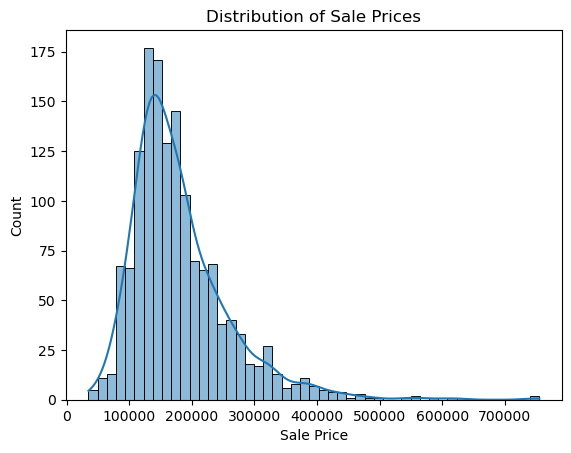

In [ ]:
#3. EDA :

#3.1 - SalesPrice Variation -

sns.histplot(df["SalePrice"],kde=True)
plt.title("Distribution of Sale Prices")
plt.xlabel("Sale Price")
plt.ylabel("Count")
plt.show()

In [21]:
df["SalePrice"].skew()

np.float64(1.8828757597682129)

In [23]:
"""
Observation: The SalePrice distribution is right-skewed, with most houses concentrated at lower-to-mid
price ranges and a smaller number of houses having very high sale prices. The skewness value of 
approximately 1.88 confirms significant positive skewness.
"""

'\nObservation: The SalePrice distribution is right-skewed, with most houses concentrated at lower-to-mid\nprice ranges and a smaller number of houses having very high sale prices. The skewness value of \napproximately 1.88 confirms significant positive skewness.\n'

In [24]:
#3.2 - Numerical features vs SalesPrice -

df.select_dtypes(include="number")

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,0,150,856,856,854,0,1710,1,0,2,1,3,1,8,0,2003.0,2,548,0,61,0,0,0,0,0,2,2008,208500
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,0,284,1262,1262,0,0,1262,0,1,2,0,3,1,6,1,1976.0,2,460,298,0,0,0,0,0,0,5,2007,181500
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,0,434,920,920,866,0,1786,1,0,2,1,3,1,6,1,2001.0,2,608,0,42,0,0,0,0,0,9,2008,223500
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,0,540,756,961,756,0,1717,1,0,1,0,3,1,7,1,1998.0,3,642,0,35,272,0,0,0,0,2,2006,140000
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,0,490,1145,1145,1053,0,2198,1,0,2,1,4,1,9,1,2000.0,3,836,192,84,0,0,0,0,0,12,2008,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,62.0,7917,6,5,1999,2000,0.0,0,0,953,953,953,694,0,1647,0,0,2,1,3,1,7,1,1999.0,2,460,0,40,0,0,0,0,0,8,2007,175000
1456,1457,20,85.0,13175,6,6,1978,1988,119.0,790,163,589,1542,2073,0,0,2073,1,0,2,0,3,1,7,2,1978.0,2,500,349,0,0,0,0,0,0,2,2010,210000
1457,1458,70,66.0,9042,7,9,1941,2006,0.0,275,0,877,1152,1188,1152,0,2340,0,0,2,0,4,1,9,2,1941.0,1,252,0,60,0,0,0,0,2500,5,2010,266500
1458,1459,20,68.0,9717,5,6,1950,1996,0.0,49,1029,0,1078,1078,0,0,1078,1,0,1,0,2,1,5,0,1950.0,1,240,366,0,112,0,0,0,0,4,2010,142125


In [25]:
corr = df.select_dtypes(include="number").corr()["SalePrice"].sort_values(ascending=False)
corr

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

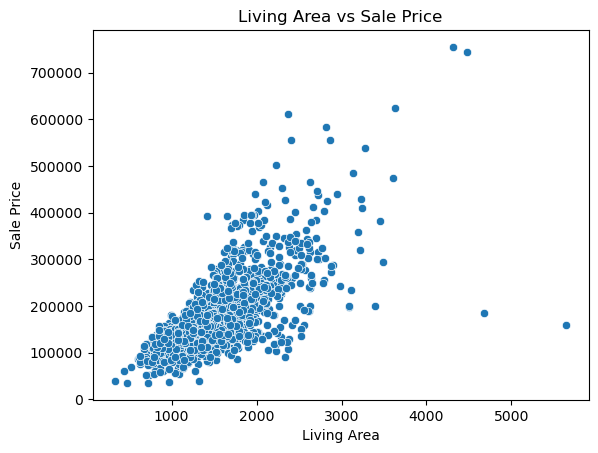

In [28]:

#3.3 - Relationship between Living Area and Sale Price

sns.scatterplot(x="GrLivArea",y="SalePrice",data=df)
plt.title("Living Area vs Sale Price")
plt.xlabel("Living Area")
plt.ylabel("Sale Price")
plt.show()

In [29]:
"""
Observation: There is a strong positive relationship between `GrLivArea` and `SalePrice`. 
In general, houses with larger above-ground living areas tend to have higher sale prices. A few unusual 
observations can also be seen, which may represent potential outliers and should be investigated before 
deciding whether to remove them.
"""

'\nObservation: There is a strong positive relationship between `GrLivArea` and `SalePrice`. \nIn general, houses with larger above-ground living areas tend to have higher sale prices. A few unusual \nobservations can also be seen, which may represent potential outliers and should be investigated before \ndeciding whether to remove them.\n'

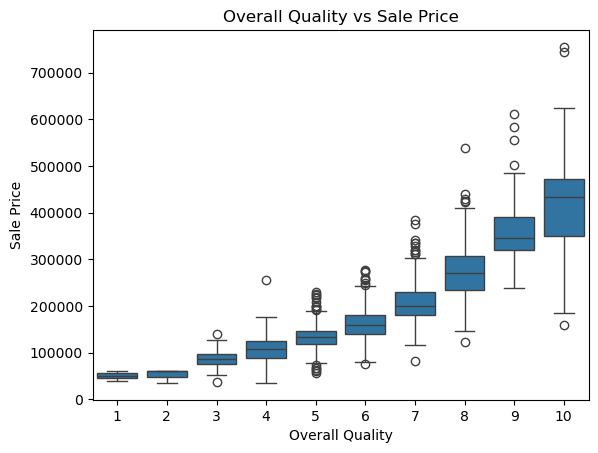

In [31]:
#3.4 - Overall Quality vs Sale Price -

sns.boxplot(x="OverallQual",y="SalePrice",data=df)
plt.title("Overall Quality vs Sale Price")
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")
plt.show()

In [32]:
"""
Observation: SalePrice generally increases with OverallQual. Houses with higher overall quality have 
substantially higher median sale prices. The spread of prices also tends to increase for higher-quality 
houses, and several potential outliers are visible.
"""

'\nObservation: SalePrice generally increases with OverallQual. Houses with higher overall quality have \nsubstantially higher median sale prices. The spread of prices also tends to increase for higher-quality \nhouses, and several potential outliers are visible.\n'

In [35]:
#3.5 - Missing values -

missing = df.isnull().sum().sort_values(ascending=False)
missing[missing>0]

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

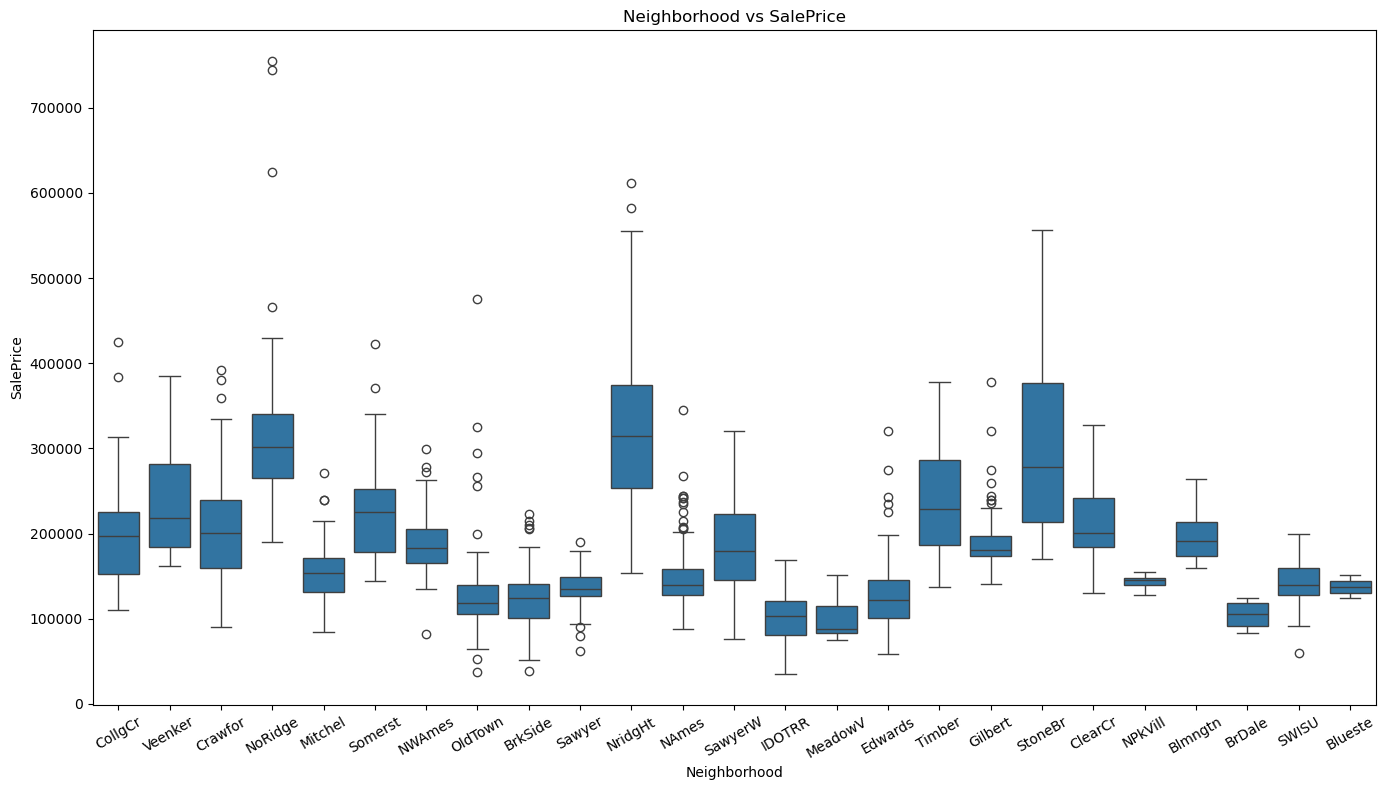

In [39]:
#3.6 - Neighborhood vs SalePrice -

plt.figure(figsize=(14,8))
sns.boxplot(x="Neighborhood",y="SalePrice",data=df)
plt.title("Neighborhood vs SalePrice")
plt.xlabel("Neighborhood")
plt.ylabel("SalePrice")
plt.xticks(rotation=30)
plt.tight_layout()

In [40]:
"""
Observation: Sale prices vary considerably across neighborhoods. Some neighborhoods have significantly 
higher median prices and wider price distributions than others, suggesting that location is an important 
factor in predicting house prices. Several outliers are also visible.
"""

'\nObservation: Sale prices vary considerably across neighborhoods. Some neighborhoods have significantly \nhigher median prices and wider price distributions than others, suggesting that location is an important \nfactor in predicting house prices. Several outliers are also visible.\n'

In [51]:
#4. Data Cleaning :

#4.1 - Missing value analysis -

missing_p = missing/len(df) * 100
missing_p.sort_values(ascending = False)[missing_p>0]

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageYrBlt      5.547945
GarageCond       5.547945
GarageType       5.547945
GarageFinish     5.547945
GarageQual       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtCond         2.534247
BsmtFinType1     2.534247
BsmtQual         2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

In [ ]:
#4.2 - Understanding missing values -

df[["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu", "GarageType"]].isnull().sum()

PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
FireplaceQu     690
GarageType       81
dtype: int64

In [50]:
df[["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu", "GarageType"]].head(10)

,PoolQC,MiscFeature,Alley,Fence,FireplaceQu,GarageType
0,NaN,NaN,NaN,NaN,NaN,Attchd
1,NaN,NaN,NaN,NaN,TA,Attchd
2,NaN,NaN,NaN,NaN,TA,Attchd
3,NaN,NaN,NaN,NaN,Gd,Detchd
4,NaN,NaN,NaN,NaN,TA,Attchd
5,NaN,Shed,NaN,MnPrv,NaN,Attchd
6,NaN,NaN,NaN,NaN,Gd,Attchd
7,NaN,Shed,NaN,NaN,TA,Attchd
8,NaN,NaN,NaN,NaN,TA,Detchd
9,NaN,NaN,NaN,NaN,TA,Attchd


In [52]:
df["LotFrontage"].describe()

count    1201.000000
mean       70.049958
std        24.284752
min        21.000000
25%        59.000000
50%        69.000000
75%        80.000000
max       313.000000
Name: LotFrontage, dtype: float64

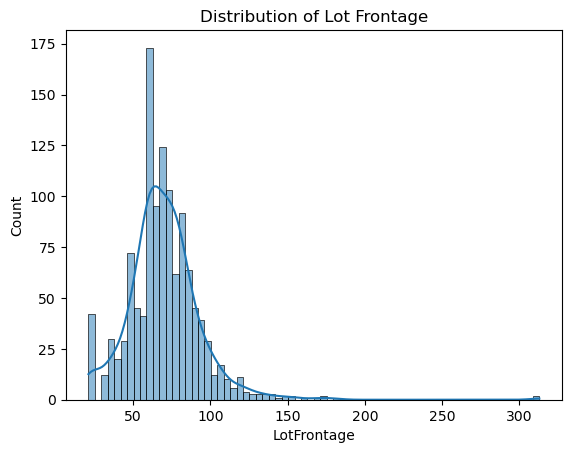

In [53]:
sns.histplot(df["LotFrontage"], kde=True)
plt.title("Distribution of Lot Frontage")
plt.show()

In [54]:
"""
**Observation:** `LotFrontage` is right-skewed and contains some large outliers. Therefore, the median is 
more suitable than the mean for imputing its missing values because the median is less affected by 
extreme values.
"""

'\n**Observation:** `LotFrontage` is right-skewed and contains some large outliers. Therefore, the median is \nmore suitable than the mean for imputing its missing values because the median is less affected by \nextreme values.\n'

In [55]:
df["Electrical"].value_counts(dropna=False)

Electrical
SBrkr    1334
FuseA      94
FuseF      27
FuseP       3
Mix         1
NaN         1
Name: count, dtype: int64

In [56]:
#4.3 - Separating features and target -

X = df.drop("SalePrice",axis=1)
y = df["SalePrice"]

print(X.shape)
print(y.shape)

(1460, 80)
(1460,)


In [57]:
#4.4 - Train-Test Split -

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

"""
Here random state = 42, makes sure that we get the same split between Train and Test 
everytime we run the notebook.
"""

'\nHere random state = 42, makes sure that we get the same split between Train and Test \neverytime we run the notebook.\n'

In [58]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1168, 80)
(292, 80)
(1168,)
(292,)


In [62]:
#4.5 - Preprocessing -

numeric_features = X_train.select_dtypes(include="number").columns
categorical_features = X_train.select_dtypes(include="object").columns

print(len(numeric_features))
print(len(categorical_features))

37
43


In [63]:
#4.5.1 - Numerical Preprocessing -

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [64]:
#4.5.2 - Categorical Preprocessing -

from sklearn.preprocessing import OneHotEncoder

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant",fill_value="None")),
    ("onehot", OneHotEncoder(handle_unknown="ignore",sparse_output=False))
])

In [65]:
#4.5.3 - Combine preprocessing -

from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num",numeric_transformer,numeric_features),
    ("cat",categorical_transformer,categorical_features)
])

In [ ]:
#4.5.4 - Testing Preprocessor -

X_train_processed = preprocessor.fit_transform(X_train)

print("Original Shape : ",X_train.shape)
print("Processed Shape : ",X_train_processed.shape)

Original Shape :  (1168, 80)
Processed Shape :  (1168, 302)


In [67]:
#4.5.5 - Transforming test data -

X_test_processed = preprocessor.transform(X_test)

print("Test Original Shape:", X_test.shape)
print("Test Processed Shape:", X_test_processed.shape)

Test Original Shape: (292, 80)
Test Processed Shape: (292, 302)


In [68]:
#4.6 - Model Training -

#4.6.1 - Training a Liner regression Model -

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_processed,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [69]:
#4.6.2 - Make Predictions -

y_pred = model.predict(X_test_processed)


print(y_pred[:10])

[160281.59622968 343247.93013651  89969.9557345  176553.17822296
 321040.84093128  67932.62455307 239494.0710462  146645.52596134
  62693.67872552 151552.01549847]


In [70]:
#4.7.1 - Calculate metrics -

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print(mae)
print(mse)
print(r2)

21126.15554353805
4269365150.767757
0.4433919711566706


In [73]:
#4.8 - Model Improvement -

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators = 200,
    random_state = 42,
    n_jobs = -1
)

rf_model.fit(X_train_processed,y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [74]:
#4.8.1 - Random Forest Predictions -

rf_pred = rf_model.predict(X_test_processed)

rf_mae = mean_absolute_error(y_test,rf_pred)
rf_mse = mean_squared_error(y_test,rf_pred)
rf_r2 = r2_score(y_test,rf_pred)

print(rf_mae)
print(rf_mse)
print(rf_r2)

17512.104160958905
835589639.0451393
0.8910620465838612


In [75]:
#4.8.2 - Model Comparison -

print("Linear Regression")
print("MAE:", mae)
print("R²:", r2)

print("\nRandom Forest")
print("MAE:", rf_mae)
print("R²:", rf_r2)

Linear Regression
MAE: 21126.15554353805
R²: 0.4433919711566706

Random Forest
MAE: 17512.104160958905
R²: 0.8910620465838612


In [77]:
#4.9 - Hyperparameter Tuning -

#4.9.1 - Define search space -

from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators" : [100,200,300,500],
    "max_depth" : [None,10,20,30],
    "min_samples_split" : [2,5,10],
    "min_samples_leaf" : [1,2,4]
}

In [108]:
#4.9.2 - Run RandomizedSearchCV -

from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_distributions = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=10,
    cv=5,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__max_depth': [None, 10, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,n_iter,10
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [80]:
#4.9.3 - Best parameters -

random_search.best_params_

{'n_estimators': 500,
 'min_samples_split': 5,
 'min_samples_leaf': 2,
 'max_depth': None}

In [83]:
#4.9.4 - Evaluate the tuned model -

best_model = random_search.best_estimator_

best_pred = best_model.predict(X_test_processed)

best_mae = mean_absolute_error(y_test,best_pred)
best_mse = mean_squared_error(y_test,best_pred)
best_r2 = r2_score(y_test,best_pred)

print(best_mae)
print(best_mse)
print(best_r2)

17611.603992137734
853793210.3696846
0.8886888005402329


In [84]:
"""
Observation -

Now thats slightly worse than our original Random Forest.
Hyperparameter tuning doesn't guarantee improvement.

Our search found parameters that performed best according to its cross-validation, but on this particular
held-out test set, the original Random Forest happened to perform slightly better.

That's actually a good result to see in a learning project rather than forcing the tuned model to 
look better.
"""

"\nObservation -\n\nNow thats slightly worse than our original Random Forest.\nHyperparameter tuning doesn't guarantee improvement.\n\nOur search found parameters that performed best according to its cross-validation, but on this particular\nheld-out test set, the original Random Forest happened to perform slightly better.\n\nThat's actually a good result to see in a learning project rather than forcing the tuned model to \nlook better.\n"

In [85]:
#4.10 - Final Model Selection -

"""
Before calling it final, though, I want to give this project one more meaningful model to compare 
against Random Forest: Gradient Boosting, because tree-boosting methods are particularly strong for 
tabular regression problems.
"""

from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train_processed, y_train)

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [ ]:
#4.10.1 - Gradient Boosting predictions -

gb_pred = gb_model.predict(X_test_processed)
gb_mae = mean_absolute_error(y_test,gb_pred)
gb_mse = mean_squared_error(y_test,gb_pred)
gb_r2 = r2_score(y_test,gb_pred)

print(gb_mae)
print(gb_mse)
print(gb_r2)

17122.511348116863
740684316.5601257
0.9034350956461146


In [88]:
"""
Observation -

Gradient Boosting is actually our best so far.
"""

'\nObservation -\n\nGradient Boosting is actually our best so far.\n'

In [89]:
#4.10.2 - Comparing all Models -

print("Linear Regression  → MAE:", mae, "R²:", r2)
print("Random Forest      → MAE:", rf_mae, "R²:", rf_r2)
print("Tuned Random Forest→ MAE:", best_mae, "R²:", best_r2)
print("Gradient Boosting  → MAE:", gb_mae, "R²:", gb_r2)

Linear Regression  → MAE: 21126.15554353805 R²: 0.4433919711566706
Random Forest      → MAE: 17512.104160958905 R²: 0.8910620465838612
Tuned Random Forest→ MAE: 17611.603992137734 R²: 0.8886888005402329
Gradient Boosting  → MAE: 17122.511348116863 R²: 0.9034350956461146


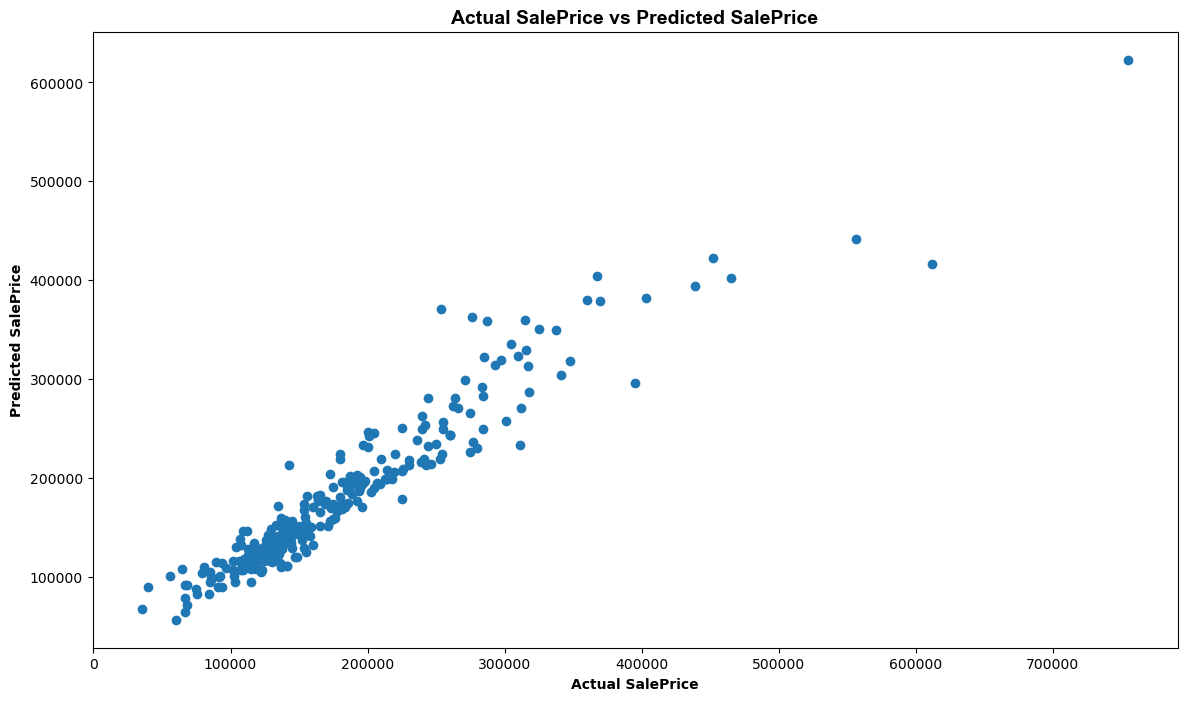

In [98]:
#4.11 - Final Model Analysis -

#4.11.1 - Actual vs Predicted -

import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))
plt.scatter(y_test,gb_pred)
plt.xlabel("Actual SalePrice",fontweight="bold")
plt.ylabel("Predicted SalePrice",fontweight="bold")
plt.title("Actual SalePrice vs Predicted SalePrice",family = "Arial",fontweight = "bold",fontsize = 14)
plt.show()

In [99]:
"""
Observation -

The closer the points are to that x=y line(diagonal line), the better the predictions.
"""

'\nObservation -\n\nThe closer the points are to that x=y line(diagonal line), the better the predictions.\n'

In [100]:
#4.11.2 - Final Model Selection -

final_model = gb_model
final_pred = gb_pred

print("Final Model: Gradient Boosting")
print("MAE:", gb_mae)
print("R²:", gb_r2)

Final Model: Gradient Boosting
MAE: 17122.511348116863
R²: 0.9034350956461146


In [102]:
#4.12 - Feature Importance -

#4.12.1 - Get feature names + importance -

feature_names = preprocessor.get_feature_names_out()

importance = pd.Series(
    final_model.feature_importances_,
    index = feature_names
).sort_values(ascending=False)

print(importance.head(15))

num__OverallQual       0.506447
num__GrLivArea         0.150804
num__GarageCars        0.047072
num__BsmtFinSF1        0.036457
num__TotalBsmtSF       0.036057
num__1stFlrSF          0.030147
num__2ndFlrSF          0.026511
num__LotArea           0.017679
num__YearBuilt         0.016651
cat__BsmtQual_Ex       0.014347
num__YearRemodAdd      0.010838
num__FullBath          0.010451
cat__KitchenQual_Ex    0.007549
num__Fireplaces        0.007030
cat__KitchenQual_Gd    0.006627
dtype: float64


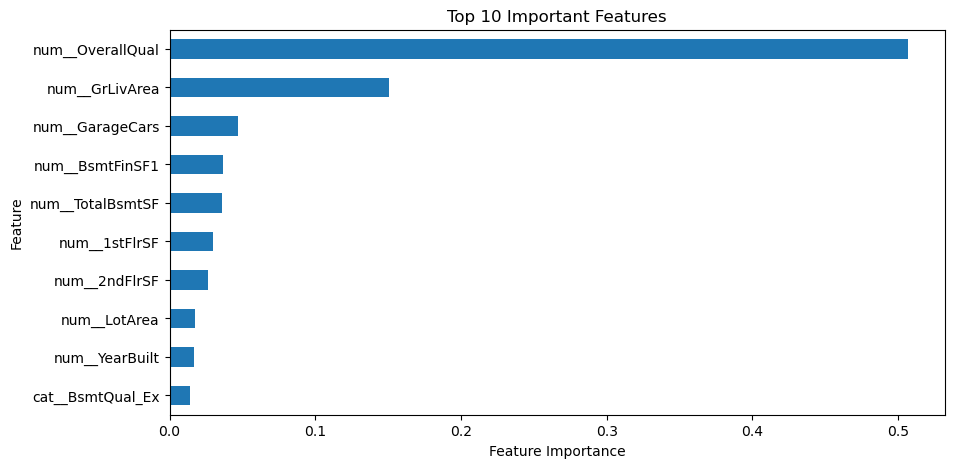

In [103]:
#4.12.2 - Plot top 10 features -

top_features = importance.head(10).sort_values()

plt.figure(figsize=(10,5))
top_features.plot(kind="barh")

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")

plt.show()

In [104]:
#4.13 - Error Analysis -

#4.13.1 - Calculate Prediction errors -

errors = y_test - final_pred

error_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": final_pred,
    "Error": errors,
    "Absolute_Error": abs(errors)
})

error_df.sort_values("Absolute_Error", ascending=False).head(10)

,Actual,Predicted,Error,Absolute_Error
898,611657,416092.487621,195564.512379,195564.512379
691,755000,622995.915576,132004.084424,132004.084424
581,253293,371092.109828,-117799.109828,117799.109828
1046,556581,441543.518970,115037.481030,115037.481030
774,395000,295927.102370,99072.897630,99072.897630
261,276000,362312.762751,-86312.762751,86312.762751
218,311500,232908.406808,78591.593192,78591.593192
1024,287000,358285.144397,-71285.144397,71285.144397
588,143000,212880.855484,-69880.855484,69880.855484
1243,465000,401794.504007,63205.495993,63205.495993


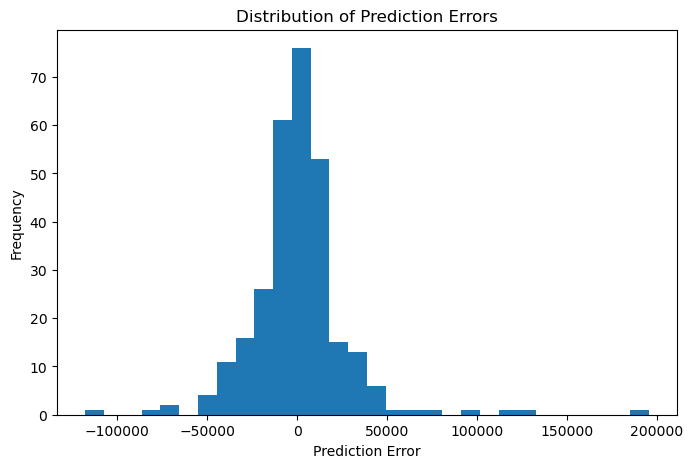

In [105]:
#4.13.2 - Error Distribution -

plt.figure(figsize=(8, 5))
plt.hist(errors, bins=30)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.show()

In [106]:
#4.14 - Save the Final Model -

#4.14.1 - Save model + preprocessor -

import joblib

joblib.dump(final_model, "house_price_model.pkl")
joblib.dump(preprocessor, "house_price_preprocessor.pkl")

"""
Why 2-models?

"house_price_preprocessor.pkl" -> This remembers how we converted raw house data into numbers.
"house_price_model.pkl" -> This remembers what the Gradient Boosting model learned from those 302 features.

2 model because suppose if we get a new feature input, the model expects the data in the same 302-feature
format it saw during training. The preprocessor converts it into format the model expects.
"""

'\nWhy 2-models?\n\n"house_price_preprocessor.pkl" -> This remembers how we converted raw house data into numbers.\n"house_price_model.pkl" -> This remembers what the Gradient Boosting model learned from those 302 features.\n\n2 model because suppose if we get a new feature input, the model expects the data in the same 302-feature\nformat it saw during training. The preprocessor converts it into format the model expects.\n'

In [107]:
#4.15 - End-to-End Prediction Test -

#4.15.1 - Predict one house -

sample_house = X_test.iloc[[0]]

sample_processed = preprocessor.transform(sample_house)

prediction = final_model.predict(sample_processed)

print("Predicted Price:", prediction[0])
print("Actual Price:", y_test.iloc[0])

Predicted Price: 144819.54416699853
Actual Price: 154500


In [ ]:
"""
## Conclusion

In this project, I built a machine learning model to predict house prices using the Ames Housing dataset.

The project included:
- Exploratory Data Analysis
- Missing value analysis
- Train-test splitting
- Numerical and categorical preprocessing
- One-hot encoding
- Feature scaling
- Linear Regression as a baseline
- Random Forest Regression
- Hyperparameter tuning using RandomizedSearchCV
- Gradient Boosting Regression
- Model evaluation using MAE and R²
- Feature importance analysis
- Prediction error analysis

Among the models tested, Gradient Boosting performed best on the test set with an R² score of
approximately 0.903 and an MAE of approximately 17,123.

The feature importance analysis showed that OverallQual and GrLivArea were among the most influential 
features for predicting SalePrice.

The project demonstrates a complete end-to-end machine learning workflow, from data exploration and 
preprocessing to model training, evaluation, and saving the trained model.
"""